# Homework Starter: Final Reporting

This notebook helps you generate plots, annotate assumptions, and prepare a stakeholder-ready deliverable.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib

## Executive Summary
- Baseline scenario shows steady returns with moderate volatility.
- Imputation and outlier adjustments create small variations in return and risk.
- Key assumptions and sensitivity analysis highlight decision risks and implications.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
np.random.seed(101)

## Load Your Data

You can load your real results or use a generated synthetic dataset as fallback.

In [3]:
data_path=Path('../../project/data/processed/sp500_sector_features_stage09.csv')
df=pd.read_csv(data_path,parse_dates=['date'])
summary=df.groupby('ticker').agg(return_mean=('daily_return','mean'),volatility=('daily_return','std')).reset_index()
summary['sharpe']=summary['return_mean']/summary['volatility']
summary

,ticker,return_mean,volatility,sharpe
0,XLB,0.000243,0.012040,0.020190
1,XLC,0.000311,0.013203,0.023580
2,XLE,0.000885,0.016179,0.054715
3,XLF,0.000396,0.011578,0.034225
4,XLI,0.000480,0.011095,0.043271
5,XLK,0.000806,0.016342,0.049340
6,XLP,0.000173,0.008624,0.020028
7,XLRE,0.000023,0.012110,0.001863
8,XLU,0.000235,0.010943,0.021471
9,XLV,0.000233,0.009547,0.024357


## Helper: Export Directory

In [4]:
img_dir = Path('reports/images')
img_dir.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(img_dir / name, dpi=300)
    print(f'Saved {name}')

## Chart 1: Risk–Return Scatter

Saved risk_return_by_sector.png


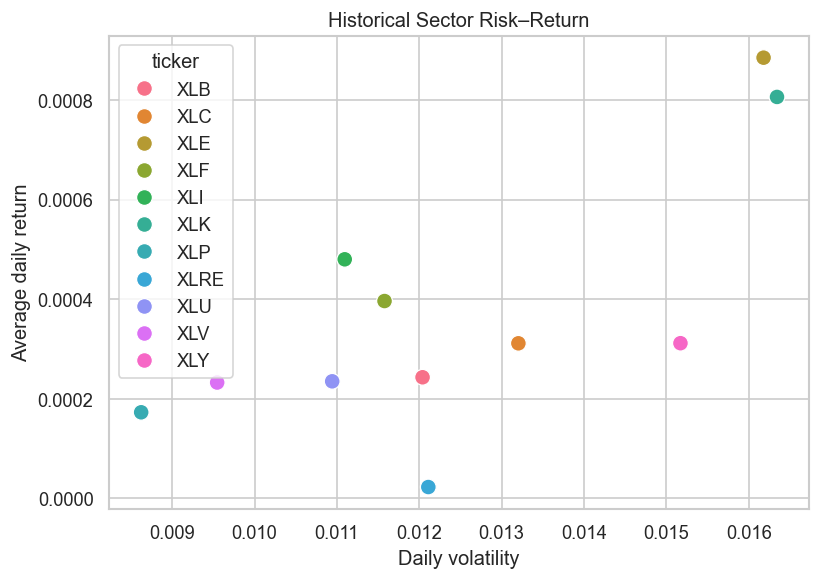

In [5]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=summary,x='volatility',y='return_mean',hue='ticker',s=90)
plt.title('Historical Sector Risk–Return')
plt.xlabel('Daily volatility'); plt.ylabel('Average daily return')
savefig('risk_return_by_sector.png'); plt.show()

## Chart 2: Return by Scenario (Bar Chart)

Saved average_return_by_sector.png


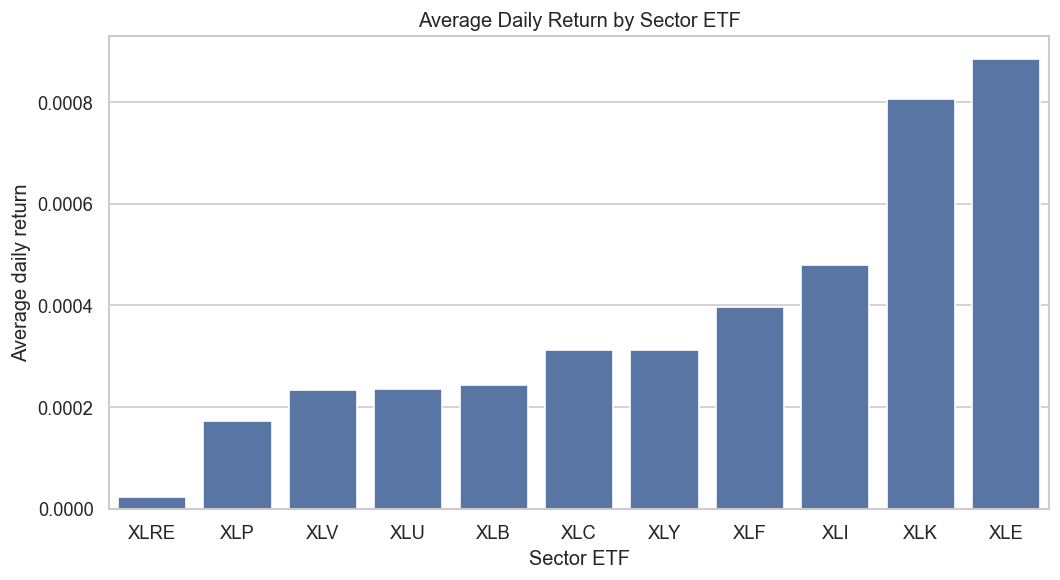

In [6]:
plt.figure(figsize=(9,5))
sns.barplot(data=summary.sort_values('return_mean'),x='ticker',y='return_mean')
plt.title('Average Daily Return by Sector ETF')
plt.xlabel('Sector ETF'); plt.ylabel('Average daily return')
savefig('average_return_by_sector.png'); plt.show()

## Chart 3: MetricA Over Time (Line Chart)

Saved volatility_by_sector.png


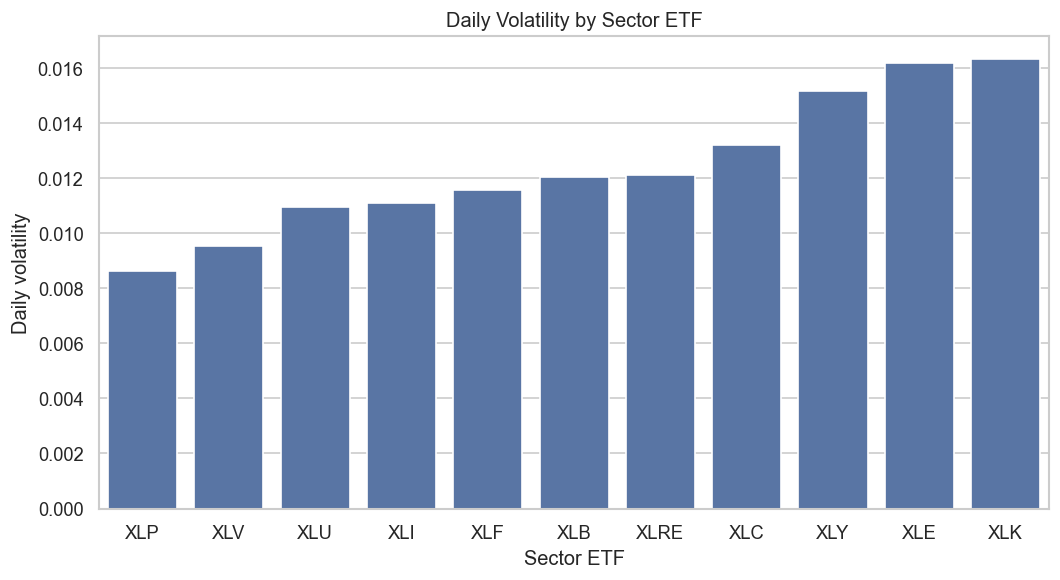

In [7]:
plt.figure(figsize=(9,5))
sns.barplot(data=summary.sort_values('volatility'),x='ticker',y='volatility')
plt.title('Daily Volatility by Sector ETF')
plt.xlabel('Sector ETF'); plt.ylabel('Daily volatility')
savefig('volatility_by_sector.png'); plt.show()

## Sensitivity Analysis / Assumptions Table

In [8]:
assumptions=pd.DataFrame({'Assumption':['Mean return','Median return'],'Value':[df['daily_return'].mean(),df['daily_return'].median()]})
assumptions

,Assumption,Value
0,Mean return,0.000372
1,Median return,0.000706


## Interpretations / Takeaways

- The risk-return chart shows whether higher historical return was associated with higher volatility.
- The return chart compares average historical performance across sector ETFs.
- The volatility chart highlights differences in historical risk.
- Results are sensitive to the date range, ETF tracking differences, and changing market conditions.

## Decision Implications

The analysis can support a portfolio manager's research review by making return-risk tradeoffs visible. It should not be used as a standalone allocation rule. The next step is to compare market regimes, drawdowns, and transaction costs.

### Save Notebook
Remember to save as `homework12_results-reporting-delivery-design_submission.ipynb`.